## Regression on Wine Quality

**Predicting the Quality Score** 

**Regression** 

**Polynomial Regression**



## Importing Dataset/ Cleaning/ Splitting

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

wine_df = pd.read_csv('data.csv')
wine_df = wine_df.dropna()
wine_df = wine_df.drop_duplicates()

X = wine_df.drop(['wine_type','quality'], axis=1)
y = wine_df['quality']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.25, random_state=42)   # 0.25 x 0.8 = 20%  - 60/20/20

In [2]:
wine_df.shape

(4421, 13)

In [3]:
X.shape

(4421, 11)

In [4]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,7.0,0.17,0.74,12.8,0.045,24.0,126.0,0.99420,3.26,0.38,12.2
1,7.7,0.64,0.21,2.2,0.077,32.0,133.0,0.99560,3.27,0.45,9.9
2,6.8,0.39,0.34,7.4,0.020,38.0,133.0,0.99212,3.18,0.44,12.0
3,6.3,0.28,0.47,11.2,0.040,61.0,183.0,0.99592,3.12,0.51,9.5
4,7.4,0.35,0.20,13.9,0.054,63.0,229.0,0.99888,3.11,0.50,8.9


In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error
degrees = range(1, 7)
train_errors = []
val_errors = []

## Fitting data into the model

In [6]:
for degree in degrees:
    poly_features = PolynomialFeatures(degree)
    X_train_poly = poly_features.fit_transform(X_train)
    X_val_poly = poly_features.transform(X_val)

    poly_model = LinearRegression()
    poly_model.fit(X_train_poly, y_train)

    train_errors.append(mean_squared_error(y_train, poly_model.predict(X_train_poly)))
    val_errors.append(mean_squared_error(y_val, poly_model.predict(X_val_poly)))

for degree, train_mse, val_mse in zip(degrees, train_errors, val_errors):
    print(f'Degree:{degree}: train MSE = {train_mse:.4f}, validation MSE = {val_mse:.4f}')

Degree:1: train MSE = 0.5361, validation MSE = 0.5716
Degree:2: train MSE = 0.4791, validation MSE = 0.5476
Degree:3: train MSE = 0.4075, validation MSE = 0.8394
Degree:4: train MSE = 0.2074, validation MSE = 299.2788
Degree:5: train MSE = 0.0639, validation MSE = 114296.3322
Degree:6: train MSE = 0.2031, validation MSE = 6829.9272


## Visualisation

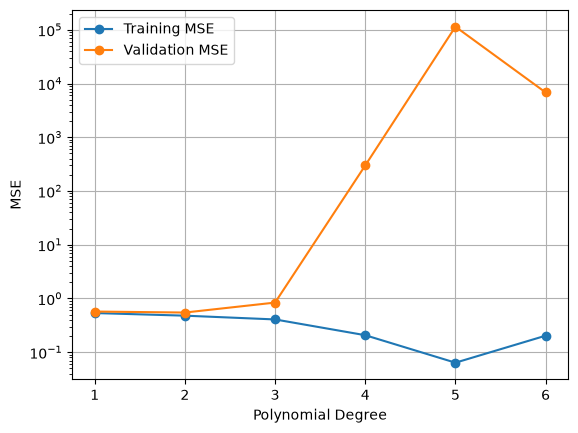

Optimal Degree: 2


In [7]:
plt.plot(degrees, train_errors, marker = 'o', label = 'Training MSE')
plt.plot(degrees, val_errors, marker = 'o', label = 'Validation MSE')
plt.yscale('log') #values too high, need to put log scale
plt.xlabel('Polynomial Degree')
plt.ylabel('MSE')
plt.legend()
plt.grid(True)
plt.show()

best_degree = list(degrees)[np.argmin(val_errors)]
print(f'Optimal Degree: {best_degree}')

### Storing your best model

In [8]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import joblib

best_degree = list(degrees)[np.argmin(val_errors)]
best_model = make_pipeline(
    PolynomialFeatures(degree=best_degree), 
    LinearRegression()
)
best_model.fit(X_train, y_train)

joblib.dump(best_model, 'best_model.joblib')


['best_model.joblib']

### Saving Variables

In [9]:
experiment_results = {
    'degrees': list(degrees),
    'train_errors': train_errors,
    'val_errors': val_errors,
    'best_degree': best_degree
}
joblib.dump(experiment_results, 'experiment_results.joblib') #saving variables to disk

['experiment_results.joblib']

### Sanity Check!

In [10]:
from assignment_1 import load_best_model

best_model_pipeline = load_best_model()

y_pred = best_model_pipeline.predict(X_test)

test_mse = mean_squared_error(y_test, y_pred)
print(f"Test MSE: {test_mse:.4f}")


Test MSE: 0.5009
